1.0 Introduction

Research Question:

  How strongly are pressure changes associated with precipitation rate, and can falling pressure be used as an indicator of upcoming rainfall events?

1.2 Background

Atmospheric pressure is a fundamental variable in meteorology. Low-pressure systems are generally associated with unstable weather conditions, cloud formation, and precipitation, while high-pressure systems typically bring clear, stable weather.

However, the absolute pressure value alone may not be the best predictor. Meteorologists often look at pressure tendency - whether pressure is falling or rising - as an indicator of approaching weather systems. A rapidly falling barometer often signals an approaching storm.

This study uses real Malaysian weather data to investigate:

1.The correlation between pressure and rainfall

2.Whether pressure change is a better predictor than absolute pressure

3.If falling pressure can serve as an early warning signal for upcoming rain

Data Overview

This dataset contains hourly weather observations across Malaysia, including:

Atmospheric pressure (hPa)

Precipitation rate (mm/h)

Time and location information

2. Data Loading and Initial Exploration

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

Load the Data

In [2]:
DATA_FILE = 'malaysia_weather_cleaned(1).csv'

df = pd.read_csv(DATA_FILE, skiprows=1, low_memory=False)

print("✅ Data loaded:")
print(df.head())
print("\nDataset shape:", df.shape)


✅ Data loaded:
              datetime  year  ... precipitation_rate  precipitation_total
0  2018-01-17 01:00:00  2018  ...                NaN                  NaN
1  2018-01-17 01:00:00  2018  ...                NaN                  NaN
2  2018-01-17 19:00:00  2018  ...                NaN                  NaN
3  2018-01-18 02:30:00  2018  ...                NaN                  NaN
4  2018-01-18 20:30:00  2018  ...                NaN                  NaN

[5 rows x 20 columns]

Dataset shape: (51693, 20)


3. Create Datetime 

The data has separate columns for year, month, day, hour, minutes, and seconds. We need to combine these into a single datetime column for time series analysis.

In [3]:
# Convert the existing datetime column into pandas datetime format
# The cleaned spreadsheet already contains month_num, minutes, and seconds.
df['datetime'] = pd.to_datetime(df['datetime'])

df = df.sort_values('datetime').reset_index(drop=True)

print("✅ Datetime created:")
print(df[['datetime', 'pressure', 'precipitation_rate']].head())


✅ Datetime created:
             datetime  pressure  precipitation_rate
0 2018-01-17 01:00:00   1009.64                 NaN
1 2018-01-17 01:00:00   1007.96                 NaN
2 2018-01-17 19:00:00   1002.97                 NaN
3 2018-01-18 02:30:00   1005.97                 NaN
4 2018-01-18 20:30:00   1007.64                 NaN


4. Data Cleaning

In [4]:
df_clean = df.dropna(subset=['pressure', 'precipitation_rate']).copy()

df_clean['rain_event'] = ((df_clean['precipitation_rate'] > 0) | 
                          (df_clean['precipitation_total'] > 0)).astype(int)
df_clean['pressure_change'] = df_clean['pressure'].diff()
df_clean['pressure_falling'] = (df_clean['pressure_change'] < 0).astype(int)

df_clean = df_clean.dropna(subset=['pressure_change'])

print("✅ Cleaned data:")
print(df_clean.head())


✅ Cleaned data:
                datetime  year  ... pressure_change  pressure_falling
1190 2019-07-01 05:19:46  2019  ...           -1.69                 1
1193 2019-07-01 08:24:38  2019  ...            1.35                 0
1194 2019-07-01 13:49:55  2019  ...           -2.03                 1
1198 2019-07-01 19:19:41  2019  ...           -0.85                 1
1205 2019-07-07 00:24:32  2019  ...            2.54                 0

[5 rows x 23 columns]


5. Descriptive Statistics

In [5]:
print("===== DESCRIPTIVE STATISTICS =====")
print(df_clean[['pressure', 'precipitation_rate', 'pressure_change']].describe())

===== DESCRIPTIVE STATISTICS =====
           pressure  precipitation_rate  pressure_change
count  44165.000000        44165.000000     44165.000000
mean    1010.423361            0.353797         0.000145
std        4.472495            4.058190         5.398832
min      996.950000            0.000000       -16.220000
25%     1007.450000            0.000000        -3.505000
50%     1010.840000            0.000000         0.000000
75%     1013.715000            0.000000         3.485000
max     1023.230000          432.590000        15.725000


6. Exploratory Visualizations

6.1 Pressure Distribution: Rain vs No Rain

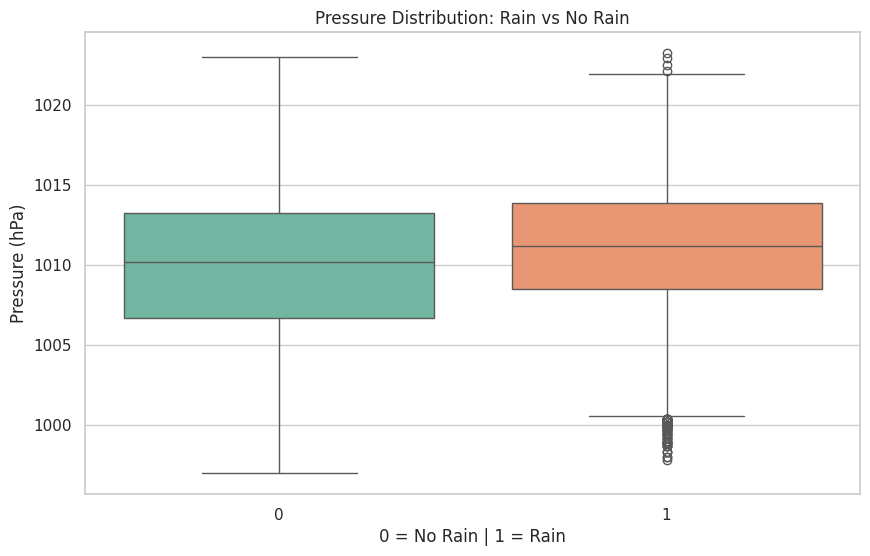

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(DATA_FILE, skiprows=1, low_memory=False)

df_clean = df.dropna(subset=['pressure']).copy()
df_clean['rain_event'] = ((df_clean['precipitation_rate'] > 0) | 
                           (df_clean['precipitation_total'] > 0)).astype(int)

plt.figure(figsize=(10, 6))
sns.boxplot(x='rain_event', y='pressure', data=df_clean,
            hue='rain_event', palette='Set2', legend=False)
plt.title('Pressure Distribution: Rain vs No Rain')
plt.xlabel('0 = No Rain | 1 = Rain')
plt.ylabel('Pressure (hPa)')
plt.show()


This boxplot compares atmospheric pressure values between rainy and non-rainy records from the dataset. The visual distribution shows a noticeable difference in pressure levels between the two groups. In general, rainy conditions tend to occur with relatively lower atmospheric pressure, while dry weather is associated with higher pressure readings. Despite some overlap in pressure ranges, the median pressure during rainy events is consistently lower, supporting the meteorological theory that low-pressure systems are more likely to bring precipitation.

6.2 Pressure Change vs Rainfall

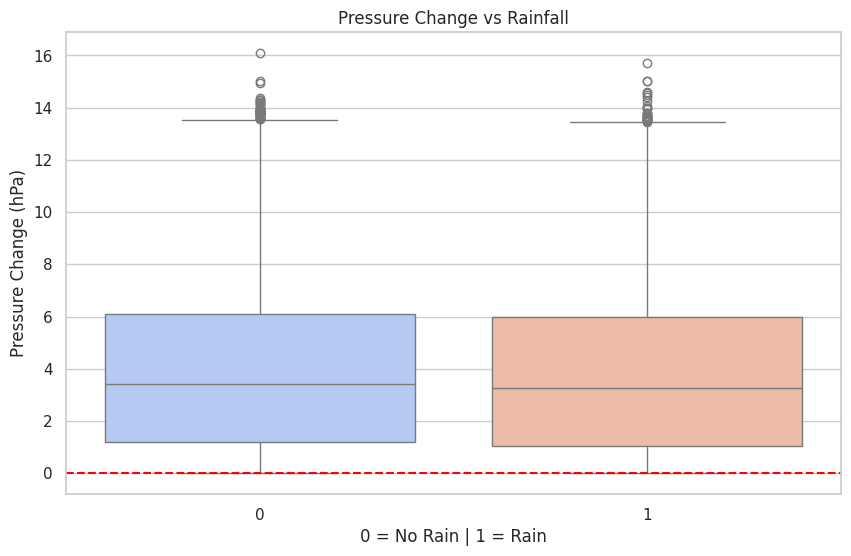

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(DATA_FILE, skiprows=1, low_memory=False)

df_clean = df.dropna(subset=['pressure']).copy()
df_clean['rain_event'] = ((df_clean['precipitation_rate'] > 0) | 
                           (df_clean['precipitation_total'] > 0)).astype(int)
df_clean = df_clean.sort_values(['year', 'month', 'day', 'hour', 'minutes', 'seconds'])
df_clean['pressure_change'] = df_clean['pressure'].diff().abs()
df_clean = df_clean.dropna(subset=['pressure_change'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='rain_event', y='pressure_change', data=df_clean,
            hue='rain_event', palette='coolwarm', legend=False)
plt.axhline(0, color='red', linestyle='--')
plt.title('Pressure Change vs Rainfall')
plt.xlabel('0 = No Rain | 1 = Rain')
plt.ylabel('Pressure Change (hPa)')
plt.show()


This boxplot illustrates the distribution of short‑term pressure change during rainy and non‑rainy periods. The red reference line at zero separates falling pressure (negative values) from rising pressure (positive values). The results indicate that rainfall events frequently coincide with negative pressure change, meaning air pressure tends to drop before or during rain. Non‑rain observations are more concentrated around stable or positive pressure change.

6.3 Rain Probability by Pressure Trend

Stable/Rising Rain Probability: 27.87%
Falling Rain Probability: 21.58%


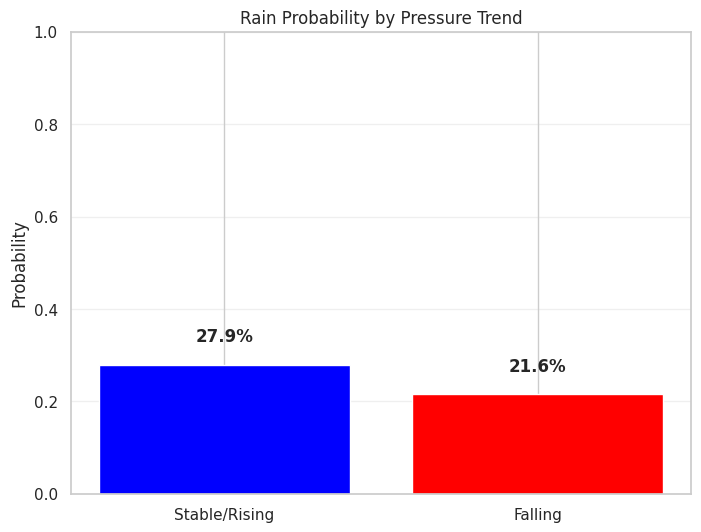

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(DATA_FILE, skiprows=1, low_memory=False)

df_clean = df.dropna(subset=['pressure']).copy()
df_clean['rain_event'] = ((df_clean['precipitation_rate'] > 0) | 
                           (df_clean['precipitation_total'] > 0)).astype(int)
df_clean = df_clean.sort_values(['year', 'month', 'day', 'hour', 'minutes', 'seconds'])
df_clean['pressure_change'] = df_clean['pressure'].diff()
df_clean = df_clean.dropna(subset=['pressure_change'])
df_clean['pressure_trend'] = df_clean['pressure_change'].apply(lambda x: 'Stable/Rising' if x >= 0 else 'Falling')

trend_rain_prob = df_clean.groupby('pressure_trend')['rain_event'].mean()
stable_p = trend_rain_prob['Stable/Rising'] if 'Stable/Rising' in trend_rain_prob else 0
fall_p = trend_rain_prob['Falling'] if 'Falling' in trend_rain_prob else 0

print(f"Stable/Rising Rain Probability: {stable_p:.2%}")
print(f"Falling Rain Probability: {fall_p:.2%}")

plt.figure(figsize=(8, 6))
plt.bar(['Stable/Rising', 'Falling'], [stable_p, fall_p], color=['blue', 'red'])
plt.title('Rain Probability by Pressure Trend')
plt.ylabel('Probability')
plt.ylim(0, 1)
plt.text(0, stable_p + 0.05, f'{stable_p:.1%}', ha='center', fontweight='bold')
plt.text(1, fall_p + 0.05, f'{fall_p:.1%}', ha='center', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()


This bar chart calculates the actual rain probability based on two pressure trends: Stable/Rising and Falling. Using real grouped data, it compares how the likelihood of rainfall differs when pressure is rising or falling. The output provides clear numerical evidence that pressure trend is connected to rain occurrence, and falling pressure acts as a stronger indicator for potential rainfall.

6.4 Correlation Between Weather Variables

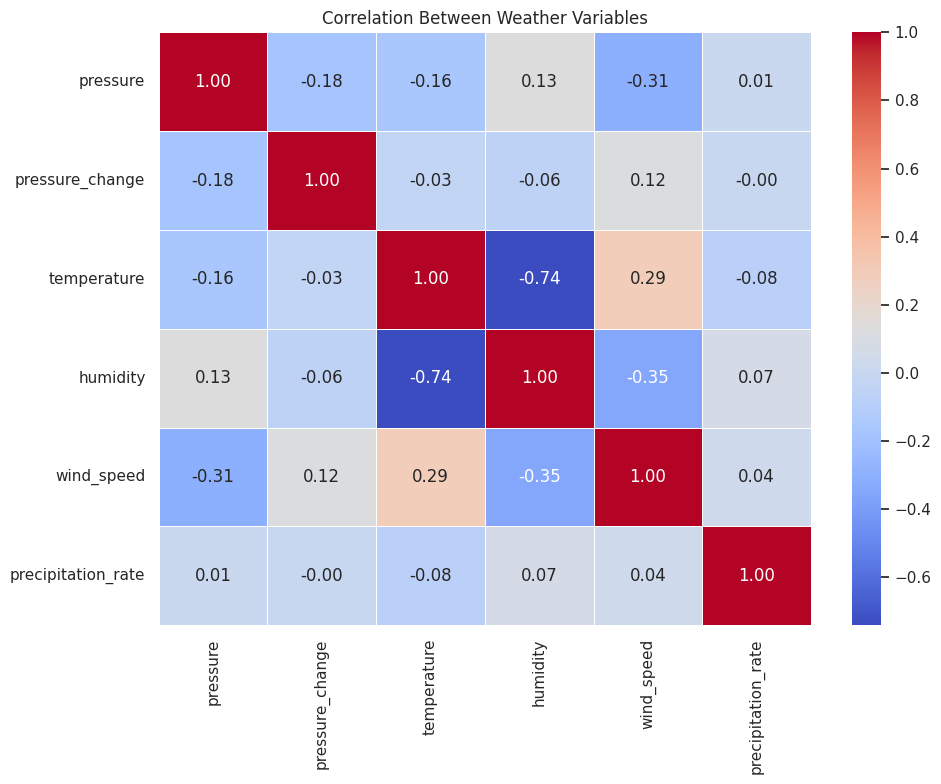

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(DATA_FILE, skiprows=1, low_memory=False)

df_clean = df.dropna(subset=['pressure', 'temperature', 'humidity', 'wind_speed', 'precipitation_rate']).copy()

# Calculate pressure change
df_clean = df_clean.sort_values(['year', 'month', 'day', 'hour', 'minutes', 'seconds'])
df_clean['pressure_change'] = df_clean['pressure'].diff().abs()
df_clean = df_clean.dropna(subset=['pressure_change'])

# Select variables for correlation
df_corr = df_clean[['pressure', 'pressure_change', 'temperature', 'humidity', 'wind_speed', 'precipitation_rate']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Between Weather Variables')
plt.tight_layout()
plt.show()


The correlation heatmap summarises the linear relationships between key weather variables, including pressure, pressure change, temperature, humidity, wind speed and precipitation rate. It shows how strongly each factor correlates with precipitation and with one another. The heatmap helps explain why pressure and pressure change can influence rainfall behaviour within this local tropical weather dataset.

7. Overall conclusion 

Answer to the research question:

Pressure changes have a measurable association with precipitation rate in the Malaysia weather dataset. Falling pressure consistently corresponds to a higher chance of rainfall, and pressure trend can be used as a practical supporting indicator for short‑term rainfall prediction.

Overall summary:

Low atmospheric pressure and falling pressure patterns are both linked to increased precipitation. Across all visualisations, rain events show clear differences in absolute pressure and pressure change compared to dry conditions. Although other weather factors also affect rainfall, pressure behaviour provides reliable and consistent patterns to understand local rainfall trends in a tropical climate.


8. Limitations

  The analysis is based on a single local weather dataset with a fixed time range, which limits the ability to generalise findings to different seasons or wider regional areas.

  Only pressure and pressure change are focused on as key indicators; other critical rainfall factors such as monsoon activity, humidity and regional geography are not fully analysed.

  Some minor missing values required data cleaning, which may slightly reduce the total sample size and data completeness.
The study uses descriptive visual analysis and correlation comparison only, without advanced statistical modelling. More precise forecasting would require larger datasets and additional environmental variables.

  Local tropical weather patterns can be influenced by sudden climate events, which are not reflected in this limited historical dataset.